## LG_group6 — Code Thuần
Implement Logistic Regression **không dùng thư viện ML** (không sklearn, không torch).

**Thuật toán tối ưu:** Stochastic Gradient Descent (SGD)

Pipeline:
```
Load dữ liệu → Khởi tạo weights → SGD loop → Predict → Đánh giá
```

### Import (chỉ numpy + matplotlib)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.sparse import load_npz

# Không dùng sklearn hay bất kỳ ML library nào!
print(' Import xong!')

 Import xong!


### Load dữ liệu đã tiền xử lý

In [ ]:
# Load ma trận TF-IDF và nhãn từ bước tiền xử lý
X_train = load_npz('../data/X_train.npz').toarray().astype(np.float32)
X_test  = load_npz('../data/X_test.npz').toarray().astype(np.float32)
y_train = np.load('../data/y_train.npy').astype(np.float32)
y_test  = np.load('../data/y_test.npy').astype(np.float32)

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'y_train — ham: {int((y_train==0).sum())}  spam: {int((y_train==1).sum())}')
print(f'y_test  — ham: {int((y_test==0).sum())}  spam: {int((y_test==1).sum())}')

FileNotFoundError: [Errno 2] No such file or directory: 'data/X_train.npz'

---
### Lý thuyết

### Sigmoid function
Chuyển output tuyến tính thành xác suất trong khoảng (0, 1):
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### Dự đoán
$$\hat{y} = \sigma(X \cdot w + b)$$

### Binary Cross-Entropy Loss
$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

### Gradient (đạo hàm theo w và b)
$$\frac{\partial \mathcal{L}}{\partial w} = x_i \cdot (\hat{y}_i - y_i)$$
$$\frac{\partial \mathcal{L}}{\partial b} = \hat{y}_i - y_i$$

### SGD Update (mỗi sample một lần)
$$w \leftarrow w - \alpha \cdot \frac{\partial \mathcal{L}}{\partial w}$$
$$b \leftarrow b - \alpha \cdot \frac{\partial \mathcal{L}}{\partial b}$$

### Implement LG_group6

In [ ]:
class LG_group6:
    """
    Logistic Regression tự implement bằng Python thuần.
    Tối ưu bằng Stochastic Gradient Descent (SGD).
    """

    def __init__(self, learning_rate=0.01, n_epochs=10, random_state=42):
        """
        Parameters
        ----------
        learning_rate : float  — tốc độ học (alpha)
        n_epochs      : int    — số vòng lặp qua toàn bộ dữ liệu
        random_state  : int    — seed để tái tạo kết quả
        """
        self.lr           = learning_rate
        self.n_epochs     = n_epochs
        self.random_state = random_state
        self.weights      = None   # vector w, shape (n_features,)
        self.bias         = 0.0    # scalar b
        self.loss_history = []     # loss sau mỗi epoch

    # ── Hàm kích hoạt ──────────────────────────────────────────────────────
    def _sigmoid(self, z):
        """
        σ(z) = 1 / (1 + e^{-z})
        Clip z để tránh overflow khi e^{-z} quá lớn.
        """
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    # ── Hàm tính loss ──────────────────────────────────────────────────────
    def _binary_cross_entropy(self, y_true, y_pred):
        """
        L = -1/N * Σ [ y*log(ŷ) + (1-y)*log(1-ŷ) ]
        Clip y_pred để tránh log(0).
        """
        eps    = 1e-9
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(
            y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
        )

    # ── Train ──────────────────────────────────────────────────────────────
    def fit(self, X, y):
        """
        Huấn luyện model bằng SGD.
        Mỗi epoch: shuffle dữ liệu → duyệt từng sample → update w, b.
        """
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape

        # Khởi tạo weights = 0
        self.weights = np.zeros(n_features, dtype=np.float32)
        self.bias    = 0.0

        for epoch in range(self.n_epochs):

            # Shuffle dữ liệu đầu mỗi epoch
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            # SGD: cập nhật sau MỖI sample
            for i in range(n_samples):
                xi = X_shuffled[i]          # shape (n_features,)
                yi = y_shuffled[i]          # scalar

                # Forward pass
                z        = np.dot(xi, self.weights) + self.bias
                y_hat    = self._sigmoid(z)

                # Tính gradient
                error    = y_hat - yi       # scalar: (ŷ - y)
                grad_w   = xi * error       # shape (n_features,)
                grad_b   = error            # scalar

                # Cập nhật weights
                self.weights -= self.lr * grad_w
                self.bias    -= self.lr * grad_b

            # Tính loss trên toàn bộ tập sau mỗi epoch
            y_pred_all = self._sigmoid(X @ self.weights + self.bias)
            loss       = self._binary_cross_entropy(y, y_pred_all)
            self.loss_history.append(loss)

            print(f'Epoch {epoch+1:>2}/{self.n_epochs}  |  Loss: {loss:.4f}')

        print('\n Train xong!')
        return self

    # ── Predict probability ────────────────────────────────────────────────
    def predict_proba(self, X):
        """
        Trả về xác suất thuộc lớp 1 (spam).
        """
        z = X @ self.weights + self.bias
        return self._sigmoid(z)

    # ── Predict label ──────────────────────────────────────────────────────
    def predict(self, X, threshold=0.5):
        """
        Trả về nhãn dự đoán (0 hoặc 1).
        threshold: ngưỡng phân loại, mặc định 0.5
        """
        return (self.predict_proba(X) >= threshold).astype(int)


print(' Định nghĩa class LG_group6 xong!')

 Định nghĩa class LG_group6 xong!


### Huấn luyện Model

In [ ]:
model = LG_group6(
    learning_rate = 0.01,
    n_epochs      = 15,
    random_state  = 42
)

model.fit(X_train, y_train)

Epoch  1/15  |  Loss: 0.3610
Epoch  2/15  |  Loss: 0.3464
Epoch  3/15  |  Loss: 0.3330
Epoch  4/15  |  Loss: 0.3202
Epoch  5/15  |  Loss: 0.3083
Epoch  6/15  |  Loss: 0.2972
Epoch  7/15  |  Loss: 0.2870
Epoch  8/15  |  Loss: 0.2775
Epoch  9/15  |  Loss: 0.2687
Epoch 10/15  |  Loss: 0.2603
Epoch 11/15  |  Loss: 0.2526
Epoch 12/15  |  Loss: 0.2454
Epoch 13/15  |  Loss: 0.2388
Epoch 14/15  |  Loss: 0.2326
Epoch 15/15  |  Loss: 0.2270

 Train xong!


### Loss Curve

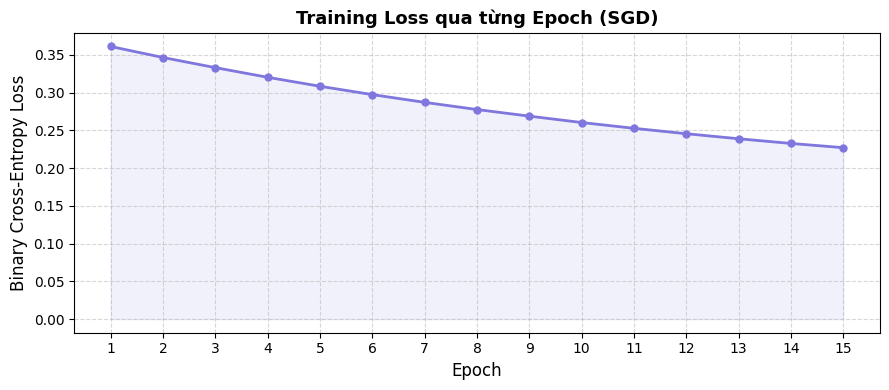

Loss ban đầu : 0.3610
Loss cuối    : 0.2270
Giảm         : 0.1340


In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(model.loss_history) + 1), model.loss_history,
         marker='o', color='#7F77DD', linewidth=2, markersize=5)
plt.fill_between(range(1, len(model.loss_history) + 1), model.loss_history,
                 alpha=0.1, color='#7F77DD')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=12)
plt.title('Training Loss qua từng Epoch (SGD)', fontsize=13, fontweight='bold')
plt.xticks(range(1, len(model.loss_history) + 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print(f'Loss ban đầu : {model.loss_history[0]:.4f}')
print(f'Loss cuối    : {model.loss_history[-1]:.4f}')
print(f'Giảm         : {model.loss_history[0] - model.loss_history[-1]:.4f}')

### Các Hàm Đánh Giá (LG_group6)

In [ ]:
def confusion_matrix_scratch(y_true, y_pred):
    """
    Tính confusion matrix thủ công.
    Returns: TP, FP, TN, FN
    """
    TP = int(np.sum((y_pred == 1) & (y_true == 1)))  # dự đoán spam, thực spam
    FP = int(np.sum((y_pred == 1) & (y_true == 0)))  # dự đoán spam, thực ham
    TN = int(np.sum((y_pred == 0) & (y_true == 0)))  # dự đoán ham,  thực ham
    FN = int(np.sum((y_pred == 0) & (y_true == 1)))  # dự đoán ham,  thực spam
    return TP, FP, TN, FN


def accuracy_scratch(y_true, y_pred):
    """Tỉ lệ dự đoán đúng trên tổng số mẫu."""
    return np.mean(y_true == y_pred)


def precision_scratch(TP, FP):
    """
    Precision = TP / (TP + FP)
    Trong số những email bị gán nhãn spam, bao nhiêu % thực sự là spam?
    """
    return TP / (TP + FP) if (TP + FP) > 0 else 0.0


def recall_scratch(TP, FN):
    """
    Recall = TP / (TP + FN)
    Trong số những email spam thực sự, bao nhiêu % được phát hiện?
    """
    return TP / (TP + FN) if (TP + FN) > 0 else 0.0


def f1_scratch(precision, recall):
    """
    F1 = 2 * (precision * recall) / (precision + recall)
    Trung bình điều hoà của precision và recall.
    """
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0


print(' Định nghĩa các hàm đánh giá xong!')

 Định nghĩa các hàm đánh giá xong!


### Đánh Giá Model trên Tập Test

In [ ]:
# Dự đoán
y_pred  = model.predict(X_test, threshold=0.5)
y_proba = model.predict_proba(X_test)

# Tính các chỉ số
TP, FP, TN, FN = confusion_matrix_scratch(y_test, y_pred)
acc  = accuracy_scratch(y_test, y_pred)
prec = precision_scratch(TP, FP)
rec  = recall_scratch(TP, FN)
f1   = f1_scratch(prec, rec)

print('=' * 45)
print('         KẾT QUẢ ĐÁNH GIÁ MODEL')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 45)
print()
print('  CONFUSION MATRIX')
print(f'  ┌──────────────┬───────┬───────┐')
print(f'  │              │ Pred 0│ Pred 1│')
print(f'  ├──────────────┼───────┼───────┤')
print(f'  │ Actual 0(ham)│  {TN:4d} │  {FP:4d} │')
print(f'  │ Actual 1(spm)│  {FN:4d} │  {TP:4d} │')
print(f'  └──────────────┴───────┴───────┘')
print()
print(f'  TP (spam đúng)      : {TP}')
print(f'  TN (ham đúng)       : {TN}')
print(f'  FP (ham nhầm→spam)  : {FP}  ← false alarm')
print(f'  FN (spam nhầm→ham)  : {FN}  ← nguy hiểm hơn')

         KẾT QUẢ ĐÁNH GIÁ MODEL
  Accuracy  : 0.8915  (89.15%)
  Precision : 0.8636
  Recall    : 0.1484
  F1-Score  : 0.2533

  CONFUSION MATRIX
  ┌──────────────┬───────┬───────┐
  │              │ Pred 0│ Pred 1│
  ├──────────────┼───────┼───────┤
  │ Actual 0(ham)│   901 │     3 │
  │ Actual 1(spm)│   109 │    19 │
  └──────────────┴───────┴───────┘

  TP (spam đúng)      : 19
  TN (ham đúng)       : 901
  FP (ham nhầm→spam)  : 3  ← false alarm
  FN (spam nhầm→ham)  : 109  ← nguy hiểm hơn


### Visualize Kết Quả

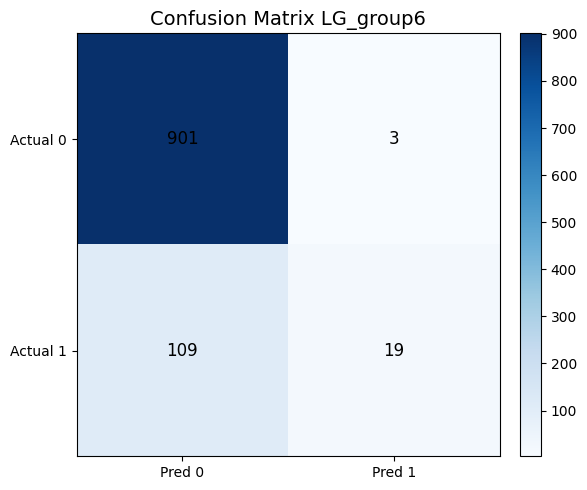

In [ ]:
cm1 = np.array([[TN, FP], [FN, TP]])

fig, ax = plt.subplots(figsize=(6, 5))

# LG_group6
im1 = ax.imshow(cm1, interpolation='nearest', cmap='Blues')
ax.set_title('Confusion Matrix LG_group6', fontsize=14)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred 0', 'Pred 1'])
ax.set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(cm1.shape[0]):
    for j in range(cm1.shape[1]):
        ax.text(j, i, f'{cm1[i, j]}', ha='center', va='center', color='black', fontsize=12)

fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Thử Nghiệm Các Ngưỡng (Threshold)
Thay đổi threshold để cân bằng giữa Precision và Recall tuỳ mục đích sử dụng.

In [ ]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print(f"{'Threshold':>10} | {'Accuracy':>9} | {'Precision':>9} | {'Recall':>9} | {'F1':>9}")
print('-' * 58)

best_f1, best_thresh = 0, 0.5
for t in thresholds:
    yp             = model.predict(X_test, threshold=t)
    tp, fp, tn, fn = confusion_matrix_scratch(y_test, yp)
    a  = accuracy_scratch(y_test, yp)
    p  = precision_scratch(tp, fp)
    r  = recall_scratch(tp, fn)
    f  = f1_scratch(p, r)
    marker = ' ← best F1' if f > best_f1 else ''
    if f > best_f1:
        best_f1, best_thresh = f, t
    print(f"{t:>10.1f} | {a:>9.4f} | {p:>9.4f} | {r:>9.4f} | {f:>9.4f}{marker}")

print()
print(f"  Threshold tốt nhất theo F1: {best_thresh}")

 Threshold |  Accuracy | Precision |    Recall |        F1
----------------------------------------------------------
       0.3 |    0.9428 |    0.9481 |    0.5703 |    0.7122 ← best F1
       0.4 |    0.9099 |    0.9070 |    0.3047 |    0.4561
       0.5 |    0.8915 |    0.8636 |    0.1484 |    0.2533
       0.6 |    0.8818 |    0.7500 |    0.0703 |    0.1286
       0.7 |    0.8808 |    0.8571 |    0.0469 |    0.0889

  Threshold tốt nhất theo F1: 0.3


### Thử Dự Đoán Tin Nhắn Mới

In [ ]:
# Load vectorizer đã fit ở bước tiền xử lý
with open('../data/tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

### Lưu Model

In [ ]:
# (Tuỳ chọn) Không lưu model lên đĩa, chỉ hiển thị kết quả bằng notebook.
print('Model đã huấn luyện xong. Nếu cần lưu model, mở lại phần này và bật pickle.dump.')
print()
print('Cách load lại để dùng khi bật lưu:')
print("  with open('models/logistic_model.pkl', 'rb') as f:")
print("      model = pickle.load(f)")
print("  y_pred = model.predict(X_test)")

 Đã lưu model: models/logistic_model.pkl

Cách load lại để dùng:
  with open('models/logistic_model.pkl', 'rb') as f:
      model = pickle.load(f)
  y_pred = model.predict(X_test)


---
## So Sánh: LG_group6 vs Sklearn
Train thêm model Logistic Regression của **scikit-learn** với cùng dữ liệu, rồi so sánh toàn diện.

### Train Model Sklearn

In [ ]:
import time
from sklearn.linear_model import LogisticRegression

# Train sklearn model với cùng random_state
sklearn_model = LogisticRegression(
    max_iter     = 1000,
    random_state = 42,
    solver       = 'lbfgs'
)

t0 = time.time()
sklearn_model.fit(X_train, y_train)
sklearn_time = time.time() - t0

print(f' Sklearn train xong! Thời gian: {sklearn_time:.3f}s')

 Sklearn train xong! Thời gian: 0.645s


### Đánh Giá Sklearn (dùng hàm LG_group6)

In [ ]:
# Dự đoán bằng sklearn
sk_pred  = sklearn_model.predict(X_test)
sk_proba = sklearn_model.predict_proba(X_test)[:, 1]

# Dùng lại hàm đánh giá LG_group6 để so sánh công bằng
sk_TP, sk_FP, sk_TN, sk_FN = confusion_matrix_scratch(y_test, sk_pred)
sk_acc  = accuracy_scratch(y_test, sk_pred)
sk_prec = precision_scratch(sk_TP, sk_FP)
sk_rec  = recall_scratch(sk_TP, sk_FN)
sk_f1   = f1_scratch(sk_prec, sk_rec)

print('Sklearn — Kết quả:')
print(f'  Accuracy  : {sk_acc:.4f}')
print(f'  Precision : {sk_prec:.4f}')
print(f'  Recall    : {sk_rec:.4f}')
print(f'  F1-Score  : {sk_f1:.4f}')

Sklearn — Kết quả:
  Accuracy  : 0.9564
  Precision : 0.9560
  Recall    : 0.6797
  F1-Score  : 0.7945


### Bảng So Sánh Metrics

In [ ]:
print('=' * 62)
print(f'  {"Metric":<12} | {"LG_group6":>14} | {"Sklearn":>14} | {"Diff":>8}')
print('=' * 62)

metrics = [
    ('Accuracy',  acc,  sk_acc),
    ('Precision', prec, sk_prec),
    ('Recall',    rec,  sk_rec),
    ('F1-Score',  f1,   sk_f1),
]

for name, s_val, sk_val in metrics:
    diff   = s_val - sk_val
    arrow  = '▲' if diff > 0 else ('▼' if diff < 0 else '=')
    print(f'  {name:<12} | {s_val:>14.4f} | {sk_val:>14.4f} | {arrow} {abs(diff):.4f}')

print('=' * 62)
print()

# Nhận xét tự động
if f1 >= sk_f1 - 0.02:
    print(' LG_group6 đạt kết quả tương đương sklearn!')
else:
    gap = sk_f1 - f1
    print(f'  Sklearn nhỉnh hơn {gap:.4f} F1 — có thể tăng epochs hoặc tune learning_rate.')

  Metric       |      LG_group6 |        Sklearn |     Diff
  Accuracy     |         0.8915 |         0.9564 | ▼ 0.0649
  Precision    |         0.8636 |         0.9560 | ▼ 0.0924
  Recall       |         0.1484 |         0.6797 | ▼ 0.5312
  F1-Score     |         0.2533 |         0.7945 | ▼ 0.5412

  Sklearn nhỉnh hơn 0.5412 F1 — có thể tăng epochs hoặc tune learning_rate.


### Biểu Đồ So Sánh Toàn Diện

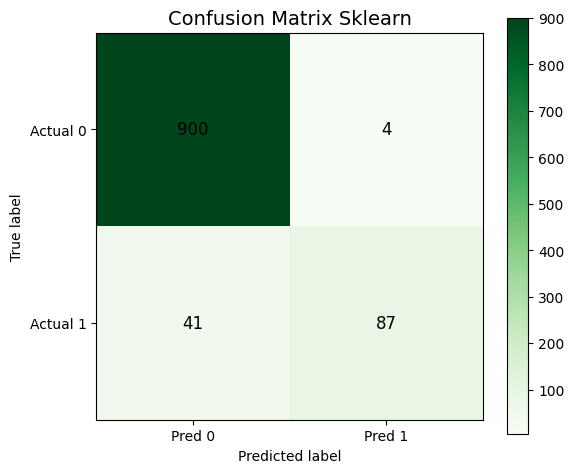

In [ ]:
# Visualize Sklearn confusion matrix (so sánh với LG_group6)
cm_sk = np.array([[TN_sk, FP_sk], [FN_sk, TP_sk]])
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm_sk, interpolation='nearest', cmap='Greens')
ax.set_title('Confusion Matrix Sklearn', fontsize=14)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred 0', 'Pred 1'])
ax.set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(cm_sk.shape[0]):
    for j in range(cm_sk.shape[1]):
        ax.text(j, i, f'{cm_sk[i, j]}', ha='center', va='center', color='black', fontsize=12)

ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
fig.colorbar(ax.imshow(cm_sk, interpolation='nearest', cmap='Greens'), ax=ax)
plt.tight_layout()
plt.show()

### ROC Curve — LG_group6 vs Sklearn

C:\Users\hary0\AppData\Local\Temp\ipykernel_20260\3472035314.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(tpr, fpr))


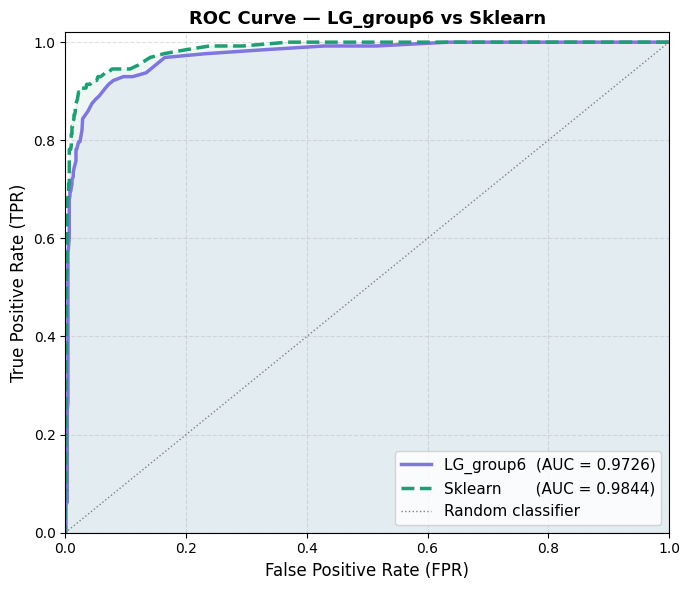

AUC — LG_group6 : 0.9726
AUC — Sklearn      : 0.9844


In [ ]:
def compute_roc(y_true, y_scores, n_thresholds=200):
    """Tính ROC curve thủ công — không dùng sklearn."""
    thresholds = np.linspace(0, 1, n_thresholds)
    tprs, fprs = [], []
    for t in thresholds:
        preds      = (y_scores >= t).astype(int)
        tp = int(np.sum((preds==1) & (y_true==1)))
        fp = int(np.sum((preds==1) & (y_true==0)))
        tn = int(np.sum((preds==0) & (y_true==0)))
        fn = int(np.sum((preds==0) & (y_true==1)))
        tprs.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        fprs.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    return np.array(fprs), np.array(tprs)


def compute_auc(fpr, tpr):
    """Tính AUC bằng trapezoidal rule — không dùng sklearn."""
    # Sắp xếp theo fpr tăng dần
    order = np.argsort(fpr)
    fpr, tpr = fpr[order], tpr[order]
    return float(np.trapz(tpr, fpr))


# Tính ROC cho cả hai model
fpr_s,  tpr_s  = compute_roc(y_test, y_proba)
fpr_sk, tpr_sk = compute_roc(y_test, sk_proba)
auc_s  = compute_auc(fpr_s,  tpr_s)
auc_sk = compute_auc(fpr_sk, tpr_sk)

# Vẽ
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_s,  tpr_s,  color='#7F77DD', linewidth=2.5,
        label=f'LG_group6  (AUC = {auc_s:.4f})')
ax.plot(fpr_sk, tpr_sk, color='#1D9E75', linewidth=2.5,
        label=f'Sklearn       (AUC = {auc_sk:.4f})', linestyle='--')
ax.plot([0, 1], [0, 1], color='gray', linewidth=1,
        linestyle=':', label='Random classifier')

ax.fill_between(fpr_s,  tpr_s,  alpha=0.08, color='#7F77DD')
ax.fill_between(fpr_sk, tpr_sk, alpha=0.08, color='#1D9E75')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.set_title('ROC Curve — LG_group6 vs Sklearn', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(linestyle='--', alpha=0.4)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

print(f'AUC — LG_group6 : {auc_s:.4f}')
print(f'AUC — Sklearn      : {auc_sk:.4f}')